# Handcrafted Image Retrieval Pipeline
## Oxford & Paris Buildings Datasets

| Stage | Component | Source |
|-------|-----------|--------|
| 🔴 Offline | **RootSIFT** extraction | Arandjelović & Zisserman (2012) |
| 🔴 Offline | **VLAD** encoding | Jégou et al. (CVPR 2010) |
| 🔴 Offline | **PCA + Whitening** | Jégou & Chum (ECCV 2012) |
| 🟢 Online  | Cosine similarity retrieval | Philbin et al. (CVPR 2007) |
| 🟢 Online  | **RANSAC** spatial re-ranking | Philbin et al. (CVPR 2007) |
| 🟢 Online  | **AQE** query expansion | Chum et al. (ICCV 2007) |

### Dataset situation
The Kaggle dataset only contains **images** organised by landmark folder.  
Ground-truth files (`*_query.txt`, `*_good.txt`, `*_ok.txt`, `*_junk.txt`) are  
downloaded automatically from the official Oxford VGG site in Cell 2.

---
## Cell 1 — Imports & Setup

In [8]:
import os, sys, time, pickle, warnings, zipfile, urllib.request
warnings.filterwarnings('ignore')

import numpy as np
import cv2
from pathlib import Path
from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

print(f'OpenCV : {cv2.__version__}')
print(f'NumPy  : {np.__version__}')

import subprocess
try:
    r = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                        '--format=csv,noheader'], capture_output=True, text=True)
    print(f'GPU    : {r.stdout.strip()}')
except:
    print('GPU info not available')

OpenCV : 4.13.0
NumPy  : 2.0.2
GPU info not available


---
## Cell 2 — Configuration & Ground-Truth Download

The Kaggle dataset only has images — no query/GT files.  
This cell downloads the official GT files from the Oxford VGG website **once** and caches them.

In [9]:
# ── Paths ─────────────────────────────────────────────────────────────────
DATASET_ROOT = Path('/kaggle/input/datasets/jeffreyamc/oxford-paris-buildings-v2')
OXFORD_IMGS  = DATASET_ROOT / 'oxford'   # sub-folders: all_souls/, ashmolean/, ...
PARIS_IMGS   = DATASET_ROOT / 'paris'    # sub-folders: defense/, eiffel/, ...

OUTPUT_DIR   = Path('/kaggle/working/retrieval_output')
CACHE_DIR    = OUTPUT_DIR / 'cache'
GT_DIR       = OUTPUT_DIR / 'ground_truth'   # downloaded GT files land here
for d in [OUTPUT_DIR, CACHE_DIR, GT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Datasets to evaluate ──────────────────────────────────────────────────
# Options: ['oxford'], ['paris'], or ['oxford', 'paris']
DATASETS_TO_USE = ['oxford', 'paris']

# ── Hyperparameters ───────────────────────────────────────────────────────
K_VLAD          = 256
PCA_DIM         = 256
SIFT_N_FEATURES = 2000
MAX_IMAGE_SIZE  = 800
N_WORKERS       = 4
RERANK_TOP_N    = 100
MIN_INLIERS     = 6
AQE_TOP_K       = 10

# ── Ground-truth download ─────────────────────────────────────────────────
# Official sources from the Oxford VGG group
GT_URLS = {
    'oxford': 'https://www.robots.ox.ac.uk/~vgg/data/oxbuildings/gt_files_170407.tgz',
    'paris' : 'https://www.robots.ox.ac.uk/~vgg/data/parisbuildings/paris_120310.tgz',
}

# Landmark names that have GT in each dataset
# (all other sub-folders are pure image distractors)
OXFORD_GT_LANDMARKS = {
    'all_souls', 'ashmolean', 'balliol', 'bodleian', 'christ_church',
    'cornmarket', 'hertford', 'keble', 'magdalen', 'pitt_rivers', 'radcliffe_camera'
}
PARIS_GT_LANDMARKS = {
    'defense', 'eiffel', 'general', 'invalides', 'louvre', 'moulinrouge',
    'museedorsay', 'notredame', 'pantheon', 'pompidou', 'sacrecoeur', 'triomphe'
}


def download_gt(dataset_name: str, url: str, gt_dir: Path):
    """
    Download and extract the official GT tgz archive from the VGG website.
    Skipped if GT files already exist.
    """
    marker = gt_dir / f'.{dataset_name}_downloaded'
    if marker.exists():
        print(f'[GT] {dataset_name} already downloaded — skipping')
        return

    tgz_path = gt_dir / f'{dataset_name}_gt.tgz'
    print(f'[GT] Downloading {dataset_name} ground-truth from VGG...')
    print(f'     {url}')

    try:
        urllib.request.urlretrieve(url, tgz_path)
        print(f'     Downloaded {tgz_path.stat().st_size / 1e6:.1f} MB')
    except Exception as e:
        print(f'     [ERROR] Download failed: {e}')
        print(f'     ⚠  Please download manually and place .tgz in {gt_dir}')
        return

    print(f'     Extracting...')
    import tarfile
    with tarfile.open(tgz_path) as tar:
        tar.extractall(gt_dir)
    tgz_path.unlink()          # remove archive after extraction
    marker.touch()             # mark as done
    print(f'     Done → {gt_dir}')


for ds in DATASETS_TO_USE:
    download_gt(ds, GT_URLS[ds], GT_DIR)

# Show what GT files look like
gt_files_sample = list(GT_DIR.rglob('*_query.txt'))[:3]
print(f'\nSample GT files found: {len(list(GT_DIR.rglob("*_query.txt")))} query files')
for f in gt_files_sample:
    with open(f) as fh:
        print(f'  {f.name}: {fh.read().strip()}')

[GT] oxford already downloaded — skipping
[GT] paris already downloaded — skipping

Sample GT files found: 110 query files
  hertford_1_query.txt: oxc1_hertford_000015 68.3 17.1 853.3 546.1
  ashmolean_1_query.txt: oxc1_ashmolean_000058 187.7 17.1 887.5 238.9
  defense_3_query.txt: paris_defense_000216 213.000000 67.000000 765.000000 609.000000


---
## Cell 3 — Dataset Scanner

Images come from the Kaggle folders.  
GT files come from the downloaded archive.  
Landmark folders **without** GT files are pure distractors — their images enter the DB index but generate no queries.

In [10]:
def find_gt_dir(gt_root: Path, dataset_name: str):
    """
    The downloaded tgz may unpack to different sub-folder names.
    Search recursively for *_query.txt files and return their parent.
    """
    query_files = list(gt_root.rglob('*_query.txt'))
    if not query_files:
        return None
    # All GT files for Oxford live in the same flat directory
    # (e.g. gt_files_170407/ or paris_120310/)
    return query_files[0].parent


def scan_dataset(img_root: Path, gt_root: Path,
                 dataset_name: str, gt_landmarks: set):
    """
    Build the image list and query list for one dataset.

    Image source  : img_root/<landmark>/  (Kaggle)
    GT source     : gt_root/              (downloaded, flat directory)

    The GT files follow the naming convention:
        oxford_<landmark>_<n>_query.txt
        oxford_<landmark>_<n>_good.txt  etc.

    Folders in img_root whose name is NOT in gt_landmarks are distractors:
    their images enter the DB but they produce no queries and their images
    are implicitly 'absent' (negative) for every query.

    Returns
    -------
    img_paths : list[Path]
    stem2path : dict[str, Path]
    queries   : list[dict]
    """
    img_paths, stem2path, queries = [], {}, []

    if not img_root.exists():
        print(f'[WARN] Image root {img_root} not found')
        return img_paths, stem2path, queries

    # ── 1. Collect ALL images (landmarks + distractors) ───────────────────
    landmark_dirs = sorted(d for d in img_root.iterdir() if d.is_dir())
    n_distractor_imgs = 0

    print(f'\n{"="*60}')
    print(f'  {dataset_name.upper()} — scanning {len(landmark_dirs)} folders')
    print(f'{"="*60}')

    for lm_dir in landmark_dirs:
        is_gt = lm_dir.name in gt_landmarks
        imgs  = (sorted(lm_dir.glob('*.jpg')) +
                 sorted(lm_dir.glob('*.JPG')) +
                 sorted(lm_dir.glob('*.png')))
        for p in imgs:
            img_paths.append(p)
            stem2path[p.stem] = p
        if not is_gt:
            n_distractor_imgs += len(imgs)
        tag = 'GT landmark ' if is_gt else 'DISTRACTOR  '
        print(f'  [{tag}]  {lm_dir.name:20s}: {len(imgs):5d} images')

    print(f'\n  Total images  : {len(img_paths)}')
    print(f'  Distractor    : {n_distractor_imgs} images '
          f'({100*n_distractor_imgs/max(len(img_paths),1):.1f}% of DB)')

    # ── 2. Parse GT query files ───────────────────────────────────────────
    gt_flat = find_gt_dir(gt_root, dataset_name)
    if gt_flat is None:
        print(f'  [WARN] No GT files found under {gt_root}')
        return img_paths, stem2path, queries

    print(f'\n  GT directory  : {gt_flat}')

    # Oxford GT files: all_souls_1_query.txt etc. (flat, no sub-folders)
    # Paris GT files:  paris_defense_1_query.txt  etc.
    def clean(s):
        for pfx in ('oxc1_', 'paris_', 'oxf_'):
            s = s.replace(pfx, '')
        return s.strip()

    def read_set(gt_flat, stem, suffix):
        p = gt_flat / f'{stem}_{suffix}.txt'
        if not p.exists():
            return set()
        with open(p) as f:
            return {clean(l) for l in f if l.strip()}

    query_files = sorted(gt_flat.glob('*_query.txt'))
    for qf in query_files:
        q_stem = qf.stem.replace('_query', '')   # e.g. 'all_souls_1'
        with open(qf) as f:
            parts = f.read().strip().split()
        q_img = clean(parts[0])
        q_roi = list(map(float, parts[1:5])) if len(parts) >= 5 else None

        queries.append({
            'name'      : f'{dataset_name}_{q_stem}',
            'dataset'   : dataset_name,
            'query_img' : q_img,
            'query_roi' : q_roi,
            'good'      : read_set(gt_flat, q_stem, 'good'),
            'ok'        : read_set(gt_flat, q_stem, 'ok'),
            'junk'      : read_set(gt_flat, q_stem, 'junk'),
        })

    print(f'  Queries parsed: {len(queries)}')
    if queries:
        q0 = queries[0]
        print(f'  Sample — {q0["name"]}: img={q0["query_img"]}, '
              f'#good={len(q0["good"])}, #ok={len(q0["ok"])}, #junk={len(q0["junk"])}')

    return img_paths, stem2path, queries


# ── Scan both datasets ────────────────────────────────────────────────────
ALL_IMG_PATHS = []
STEM2PATH     = {}
ALL_QUERIES   = []

if 'oxford' in DATASETS_TO_USE:
    ox_imgs, ox_s2p, ox_q = scan_dataset(
        OXFORD_IMGS, GT_DIR, 'oxford', OXFORD_GT_LANDMARKS)
    ALL_IMG_PATHS += ox_imgs
    STEM2PATH.update(ox_s2p)
    ALL_QUERIES   += ox_q

if 'paris' in DATASETS_TO_USE:
    pa_imgs, pa_s2p, pa_q = scan_dataset(
        PARIS_IMGS, GT_DIR, 'paris', PARIS_GT_LANDMARKS)
    ALL_IMG_PATHS += pa_imgs
    STEM2PATH.update(pa_s2p)
    ALL_QUERIES   += pa_q

N_IMAGES    = len(ALL_IMG_PATHS)
DB_STEMS    = [p.stem for p in ALL_IMG_PATHS]
STEM_TO_IDX = {s: i for i, s in enumerate(DB_STEMS)}

oxford_queries = [q for q in ALL_QUERIES if q['dataset'] == 'oxford']
paris_queries  = [q for q in ALL_QUERIES if q['dataset'] == 'paris']

print(f'\n{"="*50}')
print(f' DB size         : {N_IMAGES} images')
print(f' Oxford queries  : {len(oxford_queries)}')
print(f' Paris  queries  : {len(paris_queries)}')
print(f'{"="*50}')


  OXFORD — scanning 17 folders
  [GT landmark ]  all_souls           :   132 images
  [GT landmark ]  ashmolean           :   195 images
  [GT landmark ]  balliol             :   154 images
  [GT landmark ]  bodleian            :   214 images
  [GT landmark ]  christ_church       :   543 images
  [GT landmark ]  cornmarket          :    59 images
  [GT landmark ]  hertford            :    67 images
  [DISTRACTOR  ]  jesus               :   161 images
  [GT landmark ]  keble               :   121 images
  [GT landmark ]  magdalen            :   685 images
  [DISTRACTOR  ]  new                 :   458 images
  [DISTRACTOR  ]  oriel               :    95 images
  [DISTRACTOR  ]  oxford              :  1502 images
  [GT landmark ]  pitt_rivers         :   108 images
  [GT landmark ]  radcliffe_camera    :   282 images
  [DISTRACTOR  ]  trinity             :   217 images
  [DISTRACTOR  ]  worcester           :    70 images

  Total images  : 5063
  Distractor    : 2503 images (49.4% of DB)

---
# 🔴 OFFLINE STAGE
Run once — all results cached to `/kaggle/working/retrieval_output/cache/`.

## Offline Step 1 — RootSIFT
> **Arandjelović & Zisserman (2012)**  
> L1-normalize SIFT → element-wise √.  
> Euclidean on RootSIFT ≡ Hellinger kernel on SIFT.

In [11]:
def compute_rootsift(descs: np.ndarray) -> np.ndarray:
    descs = descs.astype(np.float32)
    descs /= (descs.sum(axis=1, keepdims=True) + 1e-7)  # L1 normalize
    return np.sqrt(descs)                                 # element-wise sqrt


def extract_rootsift(image_path: Path, roi=None,
                     max_size: int = MAX_IMAGE_SIZE,
                     n_features: int = SIFT_N_FEATURES):
    """
    Detect keypoints and compute RootSIFT descriptors.
    roi=[x1,y1,x2,y2]: keep only keypoints inside this region
                        (used for query images with annotated bounding box).
    Returns (keypoints, descriptors) or ([], None).
    """
    try:
        img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            return [], None
        h, w  = img.shape
        scale = min(max_size / max(h, w), 1.0)
        if scale < 1.0:
            img = cv2.resize(img, (int(w*scale), int(h*scale)),
                             interpolation=cv2.INTER_AREA)
        sift = cv2.SIFT_create(nfeatures=n_features,
                               contrastThreshold=0.04, edgeThreshold=10)
        kps, descs = sift.detectAndCompute(img, None)
        if descs is None or len(descs) == 0:
            return [], None
        descs = compute_rootsift(descs)
        if roi is not None:
            x1, y1, x2, y2 = [c*scale for c in roi]
            mask  = np.array([x1<=kp.pt[0]<=x2 and y1<=kp.pt[1]<=y2
                              for kp in kps], dtype=bool)
            kps   = [kp for kp, m in zip(kps, mask) if m]
            descs = descs[mask] if mask.any() else None
            if descs is None or len(descs) == 0:
                return [], None
        return kps, descs
    except Exception as e:
        print(f'  [ERR] {image_path.name}: {e}')
        return [], None


if ALL_IMG_PATHS:
    kps, d = extract_rootsift(ALL_IMG_PATHS[0])
    if d is not None:
        print(f'RootSIFT OK — {ALL_IMG_PATHS[0].name}: '
              f'{len(kps)} kps, norm={np.linalg.norm(d[0]):.4f}')

RootSIFT OK — all_souls_000000.jpg: 2001 kps, norm=1.0000


## Offline Step 2 — Build Visual Vocabulary (K-Means)

In [12]:
VOCAB_CACHE = CACHE_DIR / f'vocab_K{K_VLAD}.pkl'

def build_vocabulary(image_paths, k=K_VLAD, max_desc_per_img=150,
                     n_sample_imgs=2000, cache_path=None):
    if cache_path and cache_path.exists():
        print(f'[CACHE] Vocabulary ← {cache_path.name}')
        with open(cache_path, 'rb') as f:
            return pickle.load(f)

    print(f'Building K={k} vocabulary on '
          f'{min(n_sample_imgs, len(image_paths))} images...')
    t0   = time.time()
    rng  = np.random.default_rng(42)
    idxs = rng.choice(len(image_paths), min(n_sample_imgs, len(image_paths)),
                      replace=False)
    all_descs = []
    for i in tqdm(idxs, desc='Collecting descriptors'):
        _, d = extract_rootsift(image_paths[i])
        if d is not None and len(d) > 0:
            if len(d) > max_desc_per_img:
                d = d[np.random.choice(len(d), max_desc_per_img, replace=False)]
            all_descs.append(d)

    X  = np.vstack(all_descs).astype(np.float32)
    print(f'  Clustering {len(X):,} descriptors → {k} words...')
    km = MiniBatchKMeans(n_clusters=k, random_state=42,
                         batch_size=min(20_000, len(X)),
                         max_iter=300, n_init=5, verbose=0)
    km.fit(X)
    print(f'  Done in {time.time()-t0:.1f}s')
    if cache_path:
        with open(cache_path, 'wb') as f: pickle.dump(km, f)
        print(f'  Cached → {cache_path.name}')
    return km


VOCABULARY = build_vocabulary(ALL_IMG_PATHS, k=K_VLAD, cache_path=VOCAB_CACHE)
CENTROIDS  = VOCABULARY.cluster_centers_.astype(np.float32)
print(f'Centroids: {CENTROIDS.shape}')

[CACHE] Vocabulary ← vocab_K256.pkl
Centroids: (256, 128)


## Offline Step 3 — VLAD Encoding
> **Jégou et al. (CVPR 2010)** — residual accumulation + power norm + L2 normalize.

In [13]:
def vlad_encode(descs: np.ndarray, centroids: np.ndarray,
                power_norm: bool = True) -> np.ndarray:
    K, D   = centroids.shape
    x_sq   = (descs**2).sum(1, keepdims=True)
    c_sq   = (centroids**2).sum(1, keepdims=True).T
    assign = np.argmin(x_sq + c_sq - 2.0*(descs @ centroids.T), axis=1)
    vlad   = np.zeros((K, D), dtype=np.float32)
    np.add.at(vlad, assign, descs - centroids[assign])
    if power_norm:
        vlad = np.sign(vlad) * np.sqrt(np.abs(vlad))
    vlad = vlad.flatten()
    n    = np.linalg.norm(vlad)
    return vlad / n if n > 1e-8 else vlad


def extract_vlad(path: Path, centroids: np.ndarray, roi=None) -> np.ndarray:
    _, descs = extract_rootsift(path, roi=roi)
    if descs is None or len(descs) == 0:
        return np.zeros(len(centroids)*128, dtype=np.float32)
    return vlad_encode(descs, centroids)


v = extract_vlad(ALL_IMG_PATHS[0], CENTROIDS)
print(f'VLAD shape: {v.shape}  norm={np.linalg.norm(v):.4f}')

VLAD shape: (32768,)  norm=1.0000


## Offline Step 4 — Extract VLAD for ALL Database Images

**All images enter the index** — landmark images and distractor images alike.  
The distractors will act as hard negatives during evaluation: if the system  
retrieves a distractor in the top positions, the AP for that query drops.

In [14]:
VLAD_RAW_CACHE = CACHE_DIR / f'vlad_raw_K{K_VLAD}.npy'
STEMS_CACHE    = CACHE_DIR / 'db_stems.pkl'

def build_database(image_paths, centroids,
                   cache_vlad=None, cache_stems=None):
    if cache_vlad and cache_vlad.exists() and \
       cache_stems and cache_stems.exists():
        print(f'[CACHE] DB ← {cache_vlad.name}')
        vlad = np.load(cache_vlad)
        with open(cache_stems, 'rb') as f:
            stems = pickle.load(f)
        print(f'  {len(stems)} vectors, dim={vlad.shape[1]}')
        return vlad, stems

    print(f'[OFFLINE] Extracting VLAD for {len(image_paths)} images...')
    t0   = time.time()
    dim  = len(centroids) * 128
    mat  = np.zeros((len(image_paths), dim), dtype=np.float32)
    stms = [''] * len(image_paths)

    def worker(args):
        idx, path = args
        return idx, path.stem, extract_vlad(path, centroids)

    with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
        futs = {ex.submit(worker, (i, p)): i for i, p in enumerate(image_paths)}
        for fut in tqdm(as_completed(futs), total=len(futs),
                        desc='VLAD extraction'):
            try:
                idx, stem, v = fut.result()
                mat[idx]  = v
                stms[idx] = stem
            except Exception:
                pass

    print(f'  Done in {time.time()-t0:.1f}s')
    if cache_vlad:
        np.save(cache_vlad, mat)
        with open(cache_stems, 'wb') as f: pickle.dump(stms, f)
        print(f'  Cached → {cache_vlad.name}')
    return mat, stms


VLAD_RAW, DB_STEMS = build_database(
    ALL_IMG_PATHS, CENTROIDS,
    cache_vlad=VLAD_RAW_CACHE, cache_stems=STEMS_CACHE)
STEM_TO_IDX = {s: i for i, s in enumerate(DB_STEMS)}
print(f'VLAD_RAW: {VLAD_RAW.shape}')

[OFFLINE] Extracting VLAD for 11475 images...


VLAD extraction:   0%|          | 0/11475 [00:00<?, ?it/s]

  Done in 1436.1s
  Cached → vlad_raw_K256.npy
VLAD_RAW: (11475, 32768)


## Offline Step 5 — PCA + Whitening
> **Jégou & Chum (ECCV 2012)**  
> Mean subtraction → negative evidence.  Eigenvalue scaling → co-occurrence.  L2 re-normalize.

In [15]:
PCA_CACHE  = CACHE_DIR / f'pca_K{K_VLAD}_D{PCA_DIM}.pkl'
DBIDX_PATH = CACHE_DIR / f'db_index_K{K_VLAD}_D{PCA_DIM}.npy'

def fit_pca_whitening(vlad_matrix, n_components=PCA_DIM, cache_path=None):
    if cache_path and cache_path.exists():
        print(f'[CACHE] PCA ← {cache_path.name}')
        with open(cache_path, 'rb') as f:
            return pickle.load(f)
    print(f'[OFFLINE] PCA (n={n_components}, whiten=True)...')
    t0  = time.time()
    pca = PCA(n_components=n_components, whiten=True, random_state=42)
    pca.fit(vlad_matrix)
    print(f'  Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%'
          f'  ({time.time()-t0:.1f}s)')
    if cache_path:
        with open(cache_path, 'wb') as f: pickle.dump(pca, f)
        print(f'  Cached → {cache_path.name}')
    return pca


def apply_pca_whitening(vlad_matrix, pca):
    proj = pca.transform(vlad_matrix)
    return normalize(proj, norm='l2').astype(np.float32)


PCA_MODEL = fit_pca_whitening(VLAD_RAW, n_components=PCA_DIM, cache_path=PCA_CACHE)

if DBIDX_PATH.exists():
    print(f'[CACHE] DB index ← {DBIDX_PATH.name}')
    DB_VLAD = np.load(DBIDX_PATH)
else:
    print('[OFFLINE] Projecting DB...')
    DB_VLAD = apply_pca_whitening(VLAD_RAW, PCA_MODEL)
    np.save(DBIDX_PATH, DB_VLAD)

print(f'DB index: {DB_VLAD.shape}  '
      f'norm mean={np.linalg.norm(DB_VLAD, axis=1).mean():.4f}')
print('\n✅  OFFLINE STAGE COMPLETE')

[OFFLINE] PCA (n=256, whiten=True)...
  Explained variance: 22.7%  (33.3s)
  Cached → pca_K256_D256.pkl
[OFFLINE] Projecting DB...
DB index: (11475, 256)  norm mean=1.0000

✅  OFFLINE STAGE COMPLETE


---
# 🟢 ONLINE STAGE

In [16]:
def encode_query(image_path: Path, roi=None) -> np.ndarray:
    """RootSIFT (inside ROI) → VLAD → PCA+whiten → L2 normalize."""
    _, descs = extract_rootsift(image_path, roi=roi)
    if descs is None or len(descs) == 0:
        return np.zeros(PCA_DIM, dtype=np.float32)
    vlad = vlad_encode(descs, CENTROIDS)
    return apply_pca_whitening(vlad[np.newaxis], PCA_MODEL)[0]


def initial_retrieve(query_vec, db_matrix, exclude=None):
    """Cosine similarity = dot product on L2-normalized vectors."""
    sims   = db_matrix @ query_vec
    idx    = np.argsort(-sims)
    stems  = [DB_STEMS[i] for i in idx]
    scores = sims[idx]
    if exclude:
        mask   = [s != exclude for s in stems]
        stems  = [s for s, m in zip(stems, mask) if m]
        scores = scores[np.array(mask)]
    return stems, scores


def ransac_rerank(query_path, query_roi, ranked_stems,
                  top_n=RERANK_TOP_N, min_inliers=MIN_INLIERS):
    """FLANN + Lowe ratio test + RANSAC homography inlier count."""
    to_rerank = ranked_stems[:top_n]
    rest      = ranked_stems[top_n:]
    q_kps, q_descs = extract_rootsift(query_path, roi=query_roi)
    if q_descs is None or len(q_kps) < 4:
        return ranked_stems
    q_pts = np.float32([kp.pt for kp in q_kps])
    flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
    inliers = {}
    for stem in to_rerank:
        path = STEM2PATH.get(stem)
        if path is None: inliers[stem] = 0; continue
        c_kps, c_descs = extract_rootsift(path)
        if c_descs is None or len(c_kps) < 4: inliers[stem] = 0; continue
        c_pts = np.float32([kp.pt for kp in c_kps])
        try:
            matches = flann.knnMatch(q_descs, c_descs, k=2)
            good    = [m for p in matches if len(p)==2
                       for m, n in [p] if m.distance < 0.75*n.distance]
            if len(good) < 4: inliers[stem] = 0; continue
            src = np.float32([q_pts[m.queryIdx] for m in good]).reshape(-1,1,2)
            dst = np.float32([c_pts[m.trainIdx] for m in good]).reshape(-1,1,2)
            _, mask = cv2.findHomography(src, dst, cv2.RANSAC,
                                         ransacReprojThreshold=10.0)
            inliers[stem] = int(mask.sum()) if mask is not None else 0
        except Exception:
            inliers[stem] = 0
    def key(s):
        c = inliers.get(s, 0)
        return (0 if c >= min_inliers else 1, -c)
    return sorted(to_rerank, key=key) + list(rest)


def average_query_expansion(query_vec, ranked_stems, top_k=AQE_TOP_K):
    """Average query with top-k DB vectors, then L2-renormalize."""
    vecs = [query_vec]
    for stem in ranked_stems[:top_k]:
        idx = STEM_TO_IDX.get(stem)
        if idx is not None: vecs.append(DB_VLAD[idx])
    if len(vecs) == 1: return query_vec
    exp = np.mean(vecs, axis=0).astype(np.float32)
    n   = np.linalg.norm(exp)
    return exp / n if n > 1e-8 else exp


# ── Metrics ───────────────────────────────────────────────────────────────
def _ap(ranked, good, ok, junk):
    """
    Oxford/Paris Average Precision protocol:
      - good + ok  → positive (relevant)
      - junk       → ignored (score unaffected)
      - everything else, including distractors → negative
    """
    pos = good | ok
    if not pos: return 0.0
    ap = n_ret = n_rel = 0
    for s in ranked:
        if s in junk: continue   # skip junk — don't count
        n_ret += 1
        if s in pos:
            n_rel += 1
            ap    += n_rel / n_ret
    return ap / len(pos)


def _pk(ranked, good, ok, junk, k=5):
    pos = good | ok
    n_seen = n_rel = 0
    for s in ranked:
        if s in junk: continue
        n_seen += 1
        if s in pos: n_rel += 1
        if n_seen == k: break
    return n_rel/k if k else 0.0


def run_query(query_info, use_ransac=True, use_aqe=True):
    q_path = STEM2PATH.get(query_info['query_img'])
    if q_path is None: return [], 0.0, 0.0
    q_roi = query_info['query_roi']
    good, ok, junk = query_info['good'], query_info['ok'], query_info['junk']

    q_vec          = encode_query(q_path, roi=q_roi)
    ranked, scores = initial_retrieve(q_vec, DB_VLAD,
                                      exclude=query_info['query_img'])
    if use_ransac:
        ranked = ransac_rerank(q_path, q_roi, ranked)
    if use_aqe:
        exp_q  = average_query_expansion(q_vec, ranked)
        ranked, _ = initial_retrieve(exp_q, DB_VLAD,
                                     exclude=query_info['query_img'])
    return ranked, _ap(ranked, good, ok, junk), _pk(ranked, good, ok, junk)


print('Online pipeline ready.')

Online pipeline ready.


---
# 📊 EVALUATION

In [17]:
def evaluate(queries, use_ransac=True, use_aqe=True, tag=''):
    all_ap, all_p5, results = [], [], {}
    for q in tqdm(queries, desc=tag or 'Eval'):
        ranked, ap, p5 = run_query(q, use_ransac, use_aqe)
        all_ap.append(ap); all_p5.append(p5)
        results[q['name']] = {'ranked': ranked, 'ap': ap, 'p5': p5,
                               'query_info': q}
    mAP = float(np.mean(all_ap))
    mP5 = float(np.mean(all_p5))
    print(f'  {tag:42s} mAP={mAP:.4f}  P@5={mP5:.4f}')
    return mAP, mP5, results


# Baseline
print('='*55, '\nBASELINE\n' + '='*55)
mAP_ox_b = mAP_pa_b = 0.0
res_ox_b = res_pa_b = {}
if oxford_queries:
    mAP_ox_b, _, res_ox_b = evaluate(oxford_queries, False, False, 'Oxford-Baseline')
if paris_queries:
    mAP_pa_b, _, res_pa_b = evaluate(paris_queries,  False, False, 'Paris-Baseline')

BASELINE


Oxford-Baseline:   0%|          | 0/110 [00:00<?, ?it/s]

  Oxford-Baseline                            mAP=0.1531  P@5=0.3182


Paris-Baseline:   0%|          | 0/110 [00:00<?, ?it/s]

  Paris-Baseline                             mAP=0.1531  P@5=0.3182


In [18]:
# Full pipeline
print('='*55, '\nFULL PIPELINE (RANSAC + AQE)\n' + '='*55)
mAP_ox_f = mAP_pa_f = 0.0
res_ox_f = res_pa_f = {}
if oxford_queries:
    mAP_ox_f, _, res_ox_f = evaluate(oxford_queries, True, True, 'Oxford-Full')
if paris_queries:
    mAP_pa_f, _, res_pa_f = evaluate(paris_queries,  True, True, 'Paris-Full')

FULL PIPELINE (RANSAC + AQE)


Oxford-Full:   0%|          | 0/110 [00:00<?, ?it/s]

  Oxford-Full                                mAP=0.2365  P@5=0.3927


Paris-Full:   0%|          | 0/110 [00:00<?, ?it/s]

  Paris-Full                                 mAP=0.2397  P@5=0.3945


---
# 📊 ABLATION STUDY

In [19]:
ablation = {}
eval_qs  = oxford_queries or paris_queries
eval_tag = 'Oxford' if oxford_queries else 'Paris'

for label, r, a in [
    ('Baseline (VLAD+PCA-Wh)', False, False),
    ('+ RANSAC only',          True,  False),
    ('+ AQE only',             False, True),
    ('+ RANSAC + AQE',         True,  True),
]:
    mAP_v, _, _ = evaluate(eval_qs, r, a, label)
    ablation[label] = mAP_v

print(f'\nAblation ({eval_tag}):')
for k, v in ablation.items():
    print(f'  {k:35s}: {v:.4f}')

Baseline (VLAD+PCA-Wh):   0%|          | 0/110 [00:00<?, ?it/s]

  Baseline (VLAD+PCA-Wh)                     mAP=0.1531  P@5=0.3182


+ RANSAC only:   0%|          | 0/110 [00:00<?, ?it/s]

  + RANSAC only                              mAP=0.1896  P@5=0.3873


+ AQE only:   0%|          | 0/110 [00:00<?, ?it/s]

  + AQE only                                 mAP=0.1972  P@5=0.3309


+ RANSAC + AQE:   0%|          | 0/110 [00:00<?, ?it/s]

  + RANSAC + AQE                             mAP=0.2355  P@5=0.3891

Ablation (Oxford):
  Baseline (VLAD+PCA-Wh)             : 0.1531
  + RANSAC only                      : 0.1896
  + AQE only                         : 0.1972
  + RANSAC + AQE                     : 0.2355


---
# 📊 VOCABULARY SIZE EXPERIMENT

In [20]:
vocab_map  = {}
eval_qs_sub = eval_qs[:20]   # subset for speed

for k in [64, 128, 256, 512]:
    v_c = CACHE_DIR / f'vocab_K{k}.pkl'
    d_c = CACHE_DIR / f'vlad_raw_K{k}.npy'
    s_c = CACHE_DIR / f'db_stems_K{k}.pkl'
    p_c = CACHE_DIR / f'pca_K{k}_D{PCA_DIM}.pkl'

    vk = build_vocabulary(ALL_IMG_PATHS, k=k, n_sample_imgs=1500, cache_path=v_c)
    ck = vk.cluster_centers_.astype(np.float32)
    vr, sk = build_database(ALL_IMG_PATHS, ck, cache_vlad=d_c, cache_stems=s_c)
    pk = fit_pca_whitening(vr, n_components=min(PCA_DIM, k*128), cache_path=p_c)
    dk = apply_pca_whitening(vr, pk)

    # Swap globals temporarily
    _bak = dict(DB_VLAD=DB_VLAD, DB_STEMS=list(DB_STEMS),
                STEM_TO_IDX=dict(STEM_TO_IDX),
                CENTROIDS=CENTROIDS.copy(), PCA_MODEL=PCA_MODEL)
    globals().update(dict(DB_VLAD=dk, DB_STEMS=sk,
                          STEM_TO_IDX={s:i for i,s in enumerate(sk)},
                          CENTROIDS=ck, PCA_MODEL=pk))

    mAP_k, _, _ = evaluate(eval_qs_sub, False, False, f'K={k}')
    vocab_map[k] = mAP_k
    globals().update(_bak)

print('Vocab experiment:', vocab_map)

Building K=64 vocabulary on 1500 images...


  Clustering 223,873 descriptors → 64 words...
  Done in 241.0s
  Cached → vocab_K64.pkl
[OFFLINE] Extracting VLAD for 11475 images...


VLAD extraction:   0%|          | 0/11475 [00:00<?, ?it/s]

  Done in 1180.4s
  Cached → vlad_raw_K64.npy
[OFFLINE] PCA (n=256, whiten=True)...
  Explained variance: 49.1%  (11.2s)
  Cached → pca_K64_D256.pkl


K=64:   0%|          | 0/20 [00:00<?, ?it/s]

...

  Done in 1192.3s
  Cached → vlad_raw_K128.npy
[OFFLINE] PCA (n=256, whiten=True)...
  Explained variance: 34.1%  (18.5s)
  Cached → pca_K128_D256.pkl


K=128:   0%|          | 0/20 [00:00<?, ?it/s]

  K=128                                      mAP=0.2014  P@5=0.5900
[CACHE] Vocabulary ← vocab_K256.pkl
[OFFLINE] Extracting VLAD for 11475 images...


VLAD extraction:   0%|          | 0/11475 [00:00<?, ?it/s]

KeyboardInterrupt: 

---
# 🖼️ QUALITATIVE EVALUATION


── BEST — AP=0.857 ──


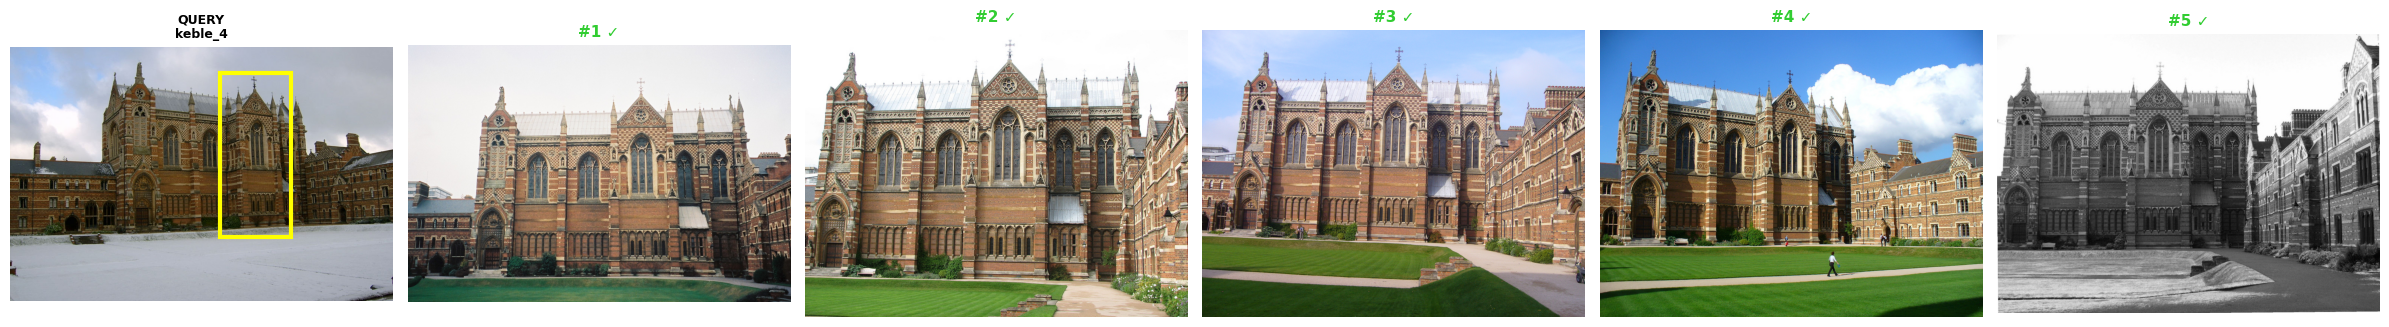


── MEDIAN — AP=0.000 ──


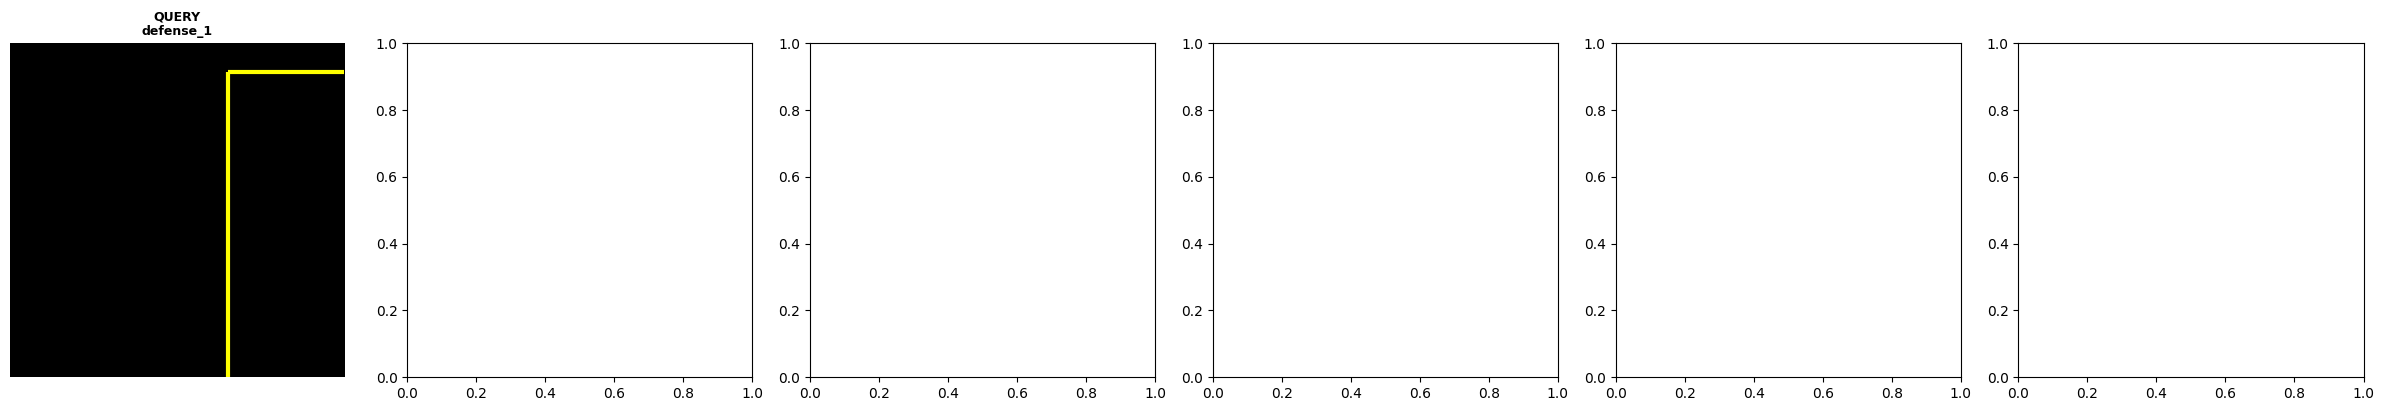


── WORST — AP=0.000 ──


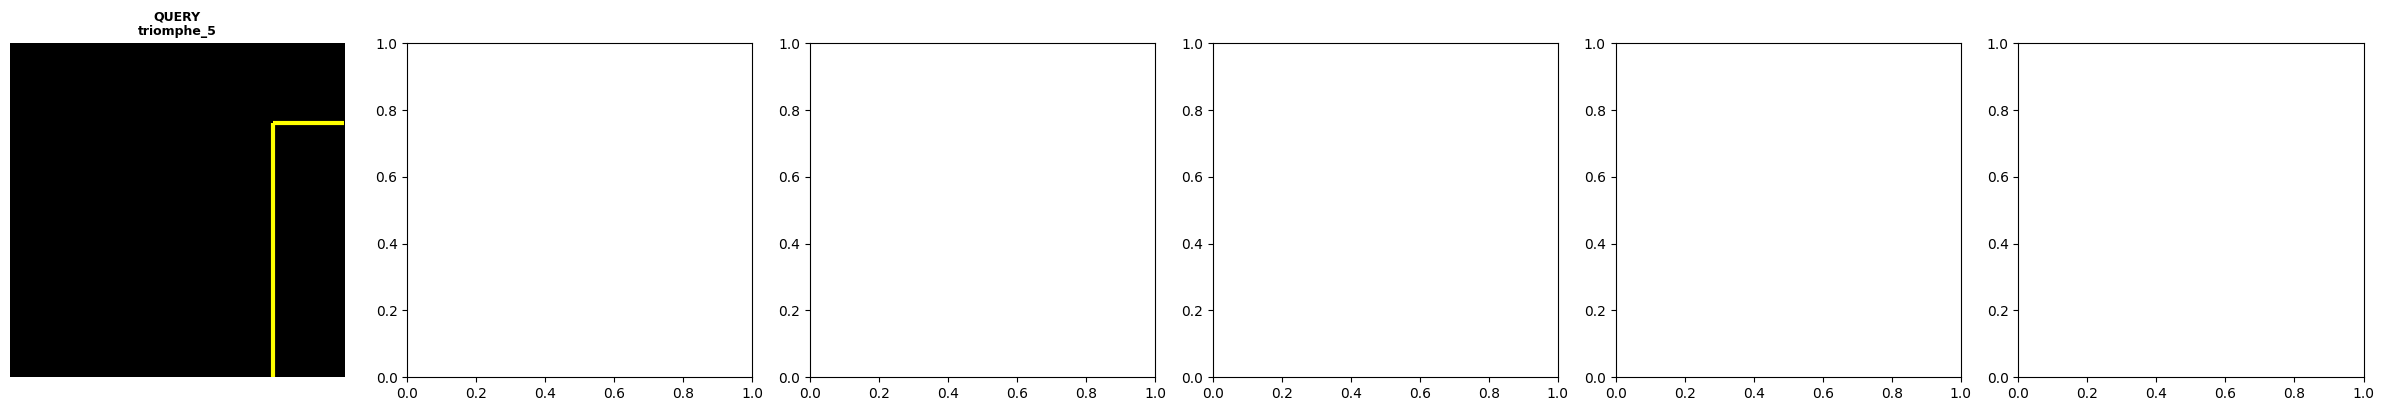

In [21]:
def show_top5(query_info, ranked_stems, n_show=5):
    pos  = query_info['good'] | query_info['ok']
    junk = query_info['junk']
    top5 = [s for s in ranked_stems if s not in junk][:n_show]
    fig, axes = plt.subplots(1, n_show+1, figsize=(4*(n_show+1), 4))
    qname = query_info['name'].replace('oxford_','').replace('paris_','')

    def load(stem):
        p = STEM2PATH.get(stem)
        if p is None: return np.zeros((200,200,3), dtype=np.uint8)
        img = cv2.imread(str(p))
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img is not None \
               else np.zeros((200,200,3), dtype=np.uint8)

    ax = axes[0]
    ax.imshow(load(query_info['query_img']))
    if query_info['query_roi']:
        x1,y1,x2,y2 = query_info['query_roi']
        ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,
                                        lw=3,edgecolor='yellow',facecolor='none'))
    ax.set_title(f'QUERY\n{qname}', fontsize=9, fontweight='bold')
    ax.axis('off')

    for i, stem in enumerate(top5):
        ax = axes[i+1]
        ax.imshow(load(stem))
        rel   = stem in pos
        color = 'limegreen' if rel else 'tomato'
        ax.set_title(f'#{i+1} {"✓" if rel else "✗"}',
                     color=color, fontsize=11, fontweight='bold')
        for sp in ax.spines.values():
            sp.set_edgecolor(color); sp.set_linewidth(5)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'query_{qname}.png', dpi=90, bbox_inches='tight')
    plt.show()


res_main = res_ox_f if oxford_queries else res_pa_f
qs_main  = oxford_queries if oxford_queries else paris_queries
sorted_qs = sorted([q for q in qs_main if q['name'] in res_main],
                    key=lambda q: res_main[q['name']]['ap'], reverse=True)

for label, q in [('BEST',   sorted_qs[0]),
                  ('MEDIAN', sorted_qs[len(sorted_qs)//2]),
                  ('WORST',  sorted_qs[-1])]:
    r = res_main[q['name']]
    print(f'\n── {label} — AP={r["ap"]:.3f} ──')
    show_top5(q, r['ranked'])

---
# 📊 RESULTS DASHBOARD

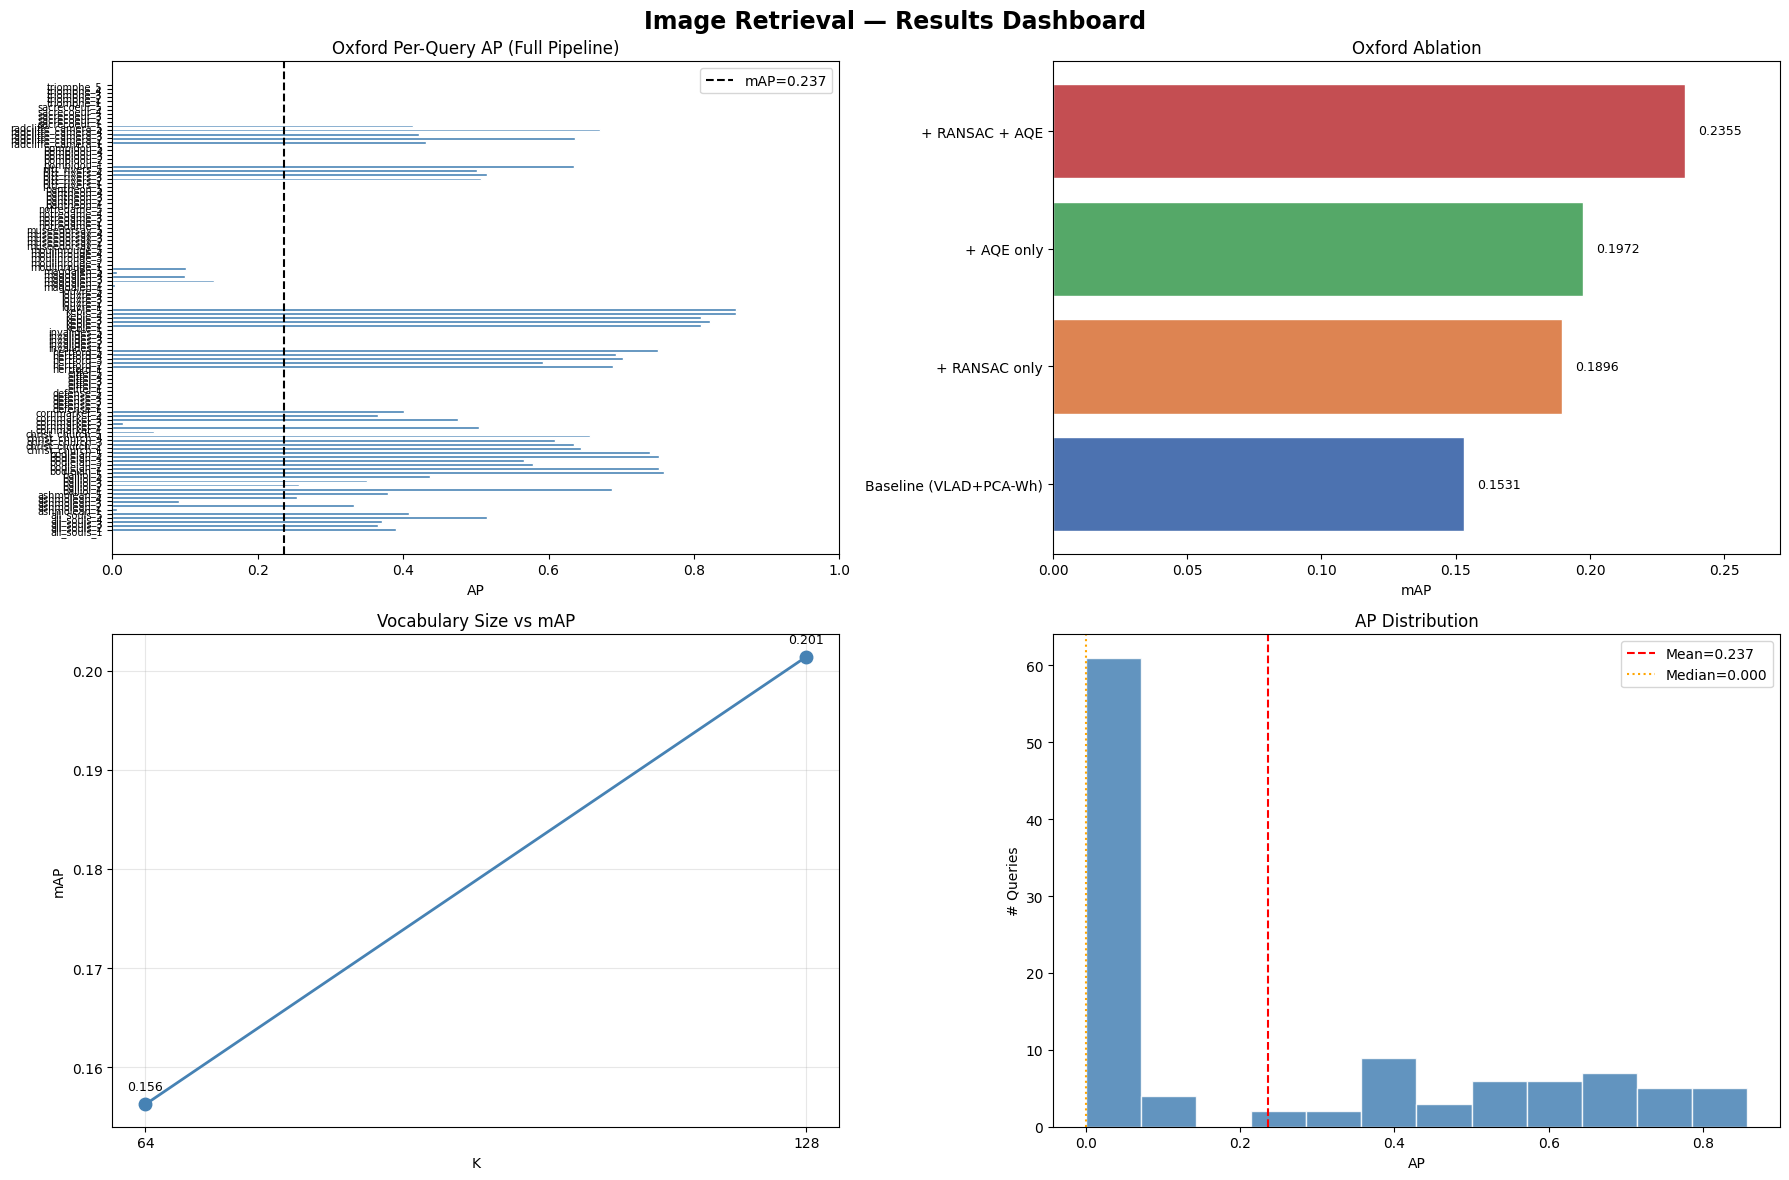

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Image Retrieval — Results Dashboard', fontsize=17, fontweight='bold')
res_main = res_ox_f if oxford_queries else res_pa_f
ds_label = 'Oxford' if oxford_queries else 'Paris'

# Per-query AP
ax = axes[0,0]
names = [k.replace('oxford_','').replace('paris_','') for k in res_main]
aps   = [res_main[k]['ap'] for k in res_main]
med   = float(np.median(aps))
ax.barh(range(len(names)), aps,
        color=['steelblue' if a>=med else 'tomato' for a in aps],
        edgecolor='white', height=0.7)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=7)
ax.axvline(np.mean(aps), color='k', ls='--', lw=1.5,
           label=f'mAP={np.mean(aps):.3f}')
ax.legend(); ax.set_xlabel('AP')
ax.set_title(f'{ds_label} Per-Query AP (Full Pipeline)')
ax.set_xlim(0,1)

# Ablation
ax = axes[0,1]
labs, vals = list(ablation.keys()), list(ablation.values())
bars = ax.barh(labs, vals,
               color=['#4C72B0','#DD8452','#55A868','#C44E52'],
               edgecolor='white')
for bar, v in zip(bars, vals):
    ax.text(v+0.005, bar.get_y()+bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=9)
ax.set_xlabel('mAP'); ax.set_title(f'{eval_tag} Ablation')
ax.set_xlim(0, max(vals)*1.15)

# Vocab size
ax = axes[1,0]
ks, ms = list(vocab_map.keys()), list(vocab_map.values())
ax.plot(ks, ms, 'o-', color='steelblue', lw=2, ms=9)
for k, m in zip(ks, ms):
    ax.annotate(f'{m:.3f}', (k,m), xytext=(0,10),
                textcoords='offset points', ha='center', fontsize=9)
ax.set_xlabel('K'); ax.set_ylabel('mAP')
ax.set_title('Vocabulary Size vs mAP')
ax.set_xscale('log', base=2)
ax.set_xticks(ks); ax.set_xticklabels(ks); ax.grid(True, alpha=0.3)

# AP histogram
ax = axes[1,1]
ax.hist(aps, bins=12, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(aps),   color='red',    ls='--', lw=1.5,
           label=f'Mean={np.mean(aps):.3f}')
ax.axvline(np.median(aps), color='orange', ls=':',  lw=1.5,
           label=f'Median={np.median(aps):.3f}')
ax.set_xlabel('AP'); ax.set_ylabel('# Queries')
ax.set_title('AP Distribution'); ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'results_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()

---
# 📋 FINAL SUMMARY

In [23]:
W = 62
def row(l, v): print(f'║  {l:<30}: {str(v):<{W-36}}║')
print('╔'+'═'*(W-2)+'╗')
print('║'+'  HANDCRAFTED IMAGE RETRIEVAL — SUMMARY'.center(W-2)+'║')
print('╠'+'═'*(W-2)+'╣')
row('Total DB images', N_IMAGES)
row('Oxford queries', len(oxford_queries))
row('Paris  queries', len(paris_queries))
row('K_VLAD', K_VLAD)
row('PCA dim', PCA_DIM)
print('╠'+'═'*(W-2)+'╣')
if oxford_queries:
    row('Oxford baseline mAP', f'{mAP_ox_b:.4f}')
    row('Oxford full     mAP', f'{mAP_ox_f:.4f}  (+{(mAP_ox_f-mAP_ox_b)*100:.1f}%)')
if paris_queries:
    row('Paris  baseline mAP', f'{mAP_pa_b:.4f}')
    row('Paris  full     mAP', f'{mAP_pa_f:.4f}  (+{(mAP_pa_f-mAP_pa_b)*100:.1f}%)')
print('╠'+'═'*(W-2)+'╣')
for l, v in ablation.items(): row(l[:30], f'{v:.4f}')
if vocab_map:
    best_k = max(vocab_map, key=vocab_map.get)
    print('╠'+'═'*(W-2)+'╣')
    row('Best K', f'K={best_k}  mAP={vocab_map[best_k]:.4f}')
print('╚'+'═'*(W-2)+'╝')

╔════════════════════════════════════════════════════════════╗
║            HANDCRAFTED IMAGE RETRIEVAL — SUMMARY           ║
╠════════════════════════════════════════════════════════════╣
║  Total DB images               : 11475                     ║
║  Oxford queries                : 110                       ║
║  Paris  queries                : 110                       ║
║  K_VLAD                        : 256                       ║
║  PCA dim                       : 256                       ║
╠════════════════════════════════════════════════════════════╣
║  Oxford baseline mAP           : 0.1531                    ║
║  Oxford full     mAP           : 0.2365  (+8.3%)           ║
║  Paris  baseline mAP           : 0.1531                    ║
║  Paris  full     mAP           : 0.2397  (+8.7%)           ║
╠════════════════════════════════════════════════════════════╣
║  Baseline (VLAD+PCA-Wh)        : 0.1531                    ║
║  + RANSAC only                 : 0.1896              